<br/>

<div align="center">
<span style="font-size: 2.5em;">Averaged Posteriors for SBI Exclusions</span>
<br/>
<span style="font-size: 1.2em; color: gray;">Average null posteriors across background realizations and compare the derived 90% exclusion with the expected limit</span>
</div>

## Overview

This notebook follows the same S1S2 signal + background setup as the training notebook, but changes the exclusion workflow.

The steps are:

1. Load the trained S1S2 signal + background model and the background event pool.
2. Generate many null spectra from background fluctuations and compute one posterior per realization.
3. Average the posteriors on the common grid and derive a 90% highest-posterior-density exclusion contour from the averaged posterior.
4. Compute the standard expected exclusion from the individual marginalized upper limits.
5. Plot both results side by side for comparison.

## 1. Setup and Configuration

Import the project utilities and point the notebook at the repository root.

In [7]:
import os
import importlib

import matplotlib.pyplot as plt
import numpy as np
import torch

desired_root_name = "xenon-sbi"
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

import utils.posteriors as posteriors
importlib.reload(posteriors)

from configs.config import PARAM_RANGES, load_model_s1s2
from utils.posteriors import (
    compute_hpd_contours,
    generate_null_spectrum_s1s2,
    plot_official_xenonnt_limit,
    posterior_grid,
    _cp_to_sigma_p,
    
)
from utils.processing import load_s1s2_valloader

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

### Model, Data, and Averaging Settings

These settings mirror the signal + background notebook, but the number of realizations is kept moderate so the averaging step remains practical in an interactive run.

In [8]:
modelname = "S1S2_signal_bg"
halo = "shm"
datatag = "low"
n_train = 300_000
bins = 10

mu_bg = 150

n_eval = 5000
n_realizations = 2000
posteriorbins = 150

logm_range = PARAM_RANGES[datatag]["logm_range"]
logcp_range = PARAM_RANGES[datatag]["logcp_range"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

signal_type = "signal_only" if mu_bg == 0 else f"signal_bg_mu{mu_bg:.0f}"
SIGNAL_PT = f"data/datasets/xenon/s1s2/pt/s1s2_n{n_train}_{halo}.pt"
bg_CSV = "data/datasets/xenon/s1s2/ers/s1s2_ers.csv"
MODELPATH = f"models/xenon/{signal_type}/{halo}/{modelname}_bins{bins}_n{n_train}_{halo}.pt"

print(f"Model path: {MODELPATH}")
print(f"Using device: {device}")
print(f"Averaging over {n_realizations} background realizations with {posteriorbins} posterior bins")

Model path: models/xenon/signal_bg_mu150/shm/S1S2_signal_bg_bins10_n300000_shm.pt
Using device: cpu
Averaging over 2000 background realizations with 150 posterior bins


### Load Model and Background Pool

This mirrors the signal + background workflow and gives us the event pool used to generate null spectra.

In [9]:
model, ckpt = load_model_s1s2(
    MODELPATH,
    bins=bins,
    modelname=modelname,
    device=device,
    print_arch=True,
)

val_loader, bg_events = load_s1s2_valloader(
    SIGNAL_PT,
    bg_CSV,
    mu_bg=mu_bg,
    bins=bins,
    n_eval=n_eval,
)

print(f"Background pool shape: {bg_events.shape}")
print(f"Validation loader batches: {len(val_loader)}")

S1S2_signal_bg(
  (net): Sequential(
    (0): Linear(in_features=102, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): SiLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): SiLU()
    (15): Dropout(p=0.2, inplace=False)
    (16): Linear(in_features=64, out_features=64, bias=True)
    (17): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_s

## 2. Local Helper Functions

The repository already provides posterior evaluation and HPD contour extraction. The notebook only adds the averaging step and a small comparison plot helper.

In [10]:
def average_background_posteriors(
    background_events,
    mu_bg,
    bins,
    model,
    logm_range,
    logcp_range,
    device,
    n_realizations=200,
    posteriorbins=150,
    seed_offset=0,
):
    """Compute and average posterior grids across many background realizations."""
    posterior_list = []
    logm_vals = None
    logcp_vals = None

    for seed in np.arange(n_realizations) + seed_offset:
        null_spectrum = generate_null_spectrum_s1s2(
            background_events=background_events,
            mu_bg=mu_bg,
            s1_bins=bins,
            s2_bins=bins,
            rng_seed=int(seed),
        )

        posterior, logm_vals_iter, logcp_vals_iter = posterior_grid(
            null_spectrum,
            logm_range=logm_range,
            logcp_range=logcp_range,
            posteriorbins=posteriorbins,
            model=model,
            device=device,
        )

        posterior_list.append(posterior.detach().cpu().numpy())
        if logm_vals is None:
            logm_vals = logm_vals_iter
            logcp_vals = logcp_vals_iter

    averaged_posterior = np.mean(np.stack(posterior_list, axis=0), axis=0)
    dlogm = logm_vals[1] - logm_vals[0]
    dlogcp = logcp_vals[1] - logcp_vals[0]
    norm = averaged_posterior.sum() * dlogm * dlogcp
    averaged_posterior = averaged_posterior / norm

    return averaged_posterior, logm_vals, logcp_vals, posterior_list

## 3. Compute the Averaged Posterior and the Expected Exclusion

Both summaries reuse the same null-realization budget so the comparison is driven only by the reduction in posterior information, not by different random samples.

In [11]:
average_posterior, logm_vals_avg, logcp_vals_avg, posterior_samples = average_background_posteriors(
    background_events=bg_events,
    mu_bg=mu_bg,
    bins=bins,
    model=model,
    logm_range=logm_range,
    logcp_range=logcp_range,
    device=device,
    n_realizations=n_realizations,
    posteriorbins=posteriorbins,
)

In [12]:
posterior_threshold, posterior_contours = compute_hpd_contours(
    average_posterior,
    logm_vals_avg,
    logcp_vals_avg,
    cl=0.90,
)

## 4. Final Comparison

This final figure matches the styling of `plot_hpd_and_marginalized_comparison()` as closely as possible, but replaces the uncertainty band with the signal-only exclusion contour and keeps the SR0 expected XENONnT curve.

In [13]:
signal_only_type = "signal_only"
signal_only_modelname = "S1S2_signal"
signal_only_modelpath = f"models/xenon/{signal_only_type}/{halo}/{signal_only_modelname}_bins{bins}_n{n_train}_{halo}.pt"
print(f"Loading signal-only model from:\n{signal_only_modelpath}\n")
signal_only_model, _ = load_model_s1s2(
    signal_only_modelpath,
    bins=bins,
    modelname=signal_only_modelname,
    device=device,
    print_arch=False,
)

signal_only_null_spectrum = torch.zeros(bins * bins, dtype=torch.float32)
signal_only_posterior, signal_only_logm_vals, signal_only_logcp_vals = posterior_grid(
    signal_only_null_spectrum,
    logm_range=logm_range,
    logcp_range=logcp_range,
    posteriorbins=posteriorbins,
    model=signal_only_model,
    device=device,
)
_signal_only_threshold, signal_only_contours = compute_hpd_contours(
    signal_only_posterior.detach().cpu().numpy(),
    signal_only_logm_vals,
    signal_only_logcp_vals,
    cl=0.90,
)

Loading signal-only model from:
models/xenon/signal_only/shm/S1S2_signal_bins10_n300000_shm.pt



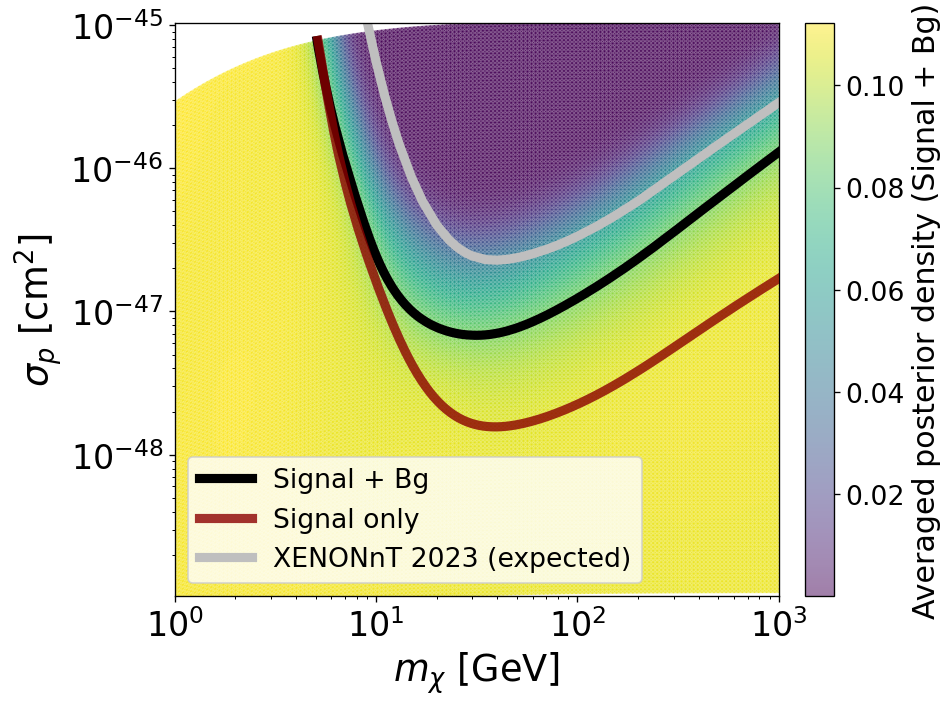

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

# Underlay: averaged posterior in sigma-space (semi-transparent)
m_vals = 10 ** logm_vals_avg
cp_vals = 10 ** logcp_vals_avg
m_mesh, cp_mesh = np.meshgrid(m_vals, cp_vals, indexing="xy")
sigma_mesh = _cp_to_sigma_p(m_mesh, cp_mesh)
average_posterior_sigma = 0.5 * average_posterior

#ax.contourf(
#    m_mesh,
#    sigma_mesh,
#    average_posterior_sigma,
#    levels=50,
#    cmap="viridis",
#    alpha=0.8,
#    zorder=0,
#)

mesh = ax.pcolormesh(
    m_mesh,
    sigma_mesh,
    average_posterior_sigma,
    cmap="viridis",
    alpha=0.5,
    shading="gouraud",   # smooth interpolation, no cell edges
    zorder=0,
    rasterized=True,     # keeps the PDF small and avoids vector seams
)

# Averaged posterior HPD contour for signal+background
for contour in posterior_contours:
    m_c, cp_c = 10 ** contour[:, 0], 10 ** contour[:, 1]
    y_c = _cp_to_sigma_p(m_c, cp_c)
    ax.plot(
        m_c,
        y_c,
        color="black",
        linewidth=5.5,
        linestyle="-",
        label="Signal + Bg",
        zorder=3,
    )
    break

# Signal-only HPD contour
for contour in signal_only_contours:
    m_c, cp_c = 10 ** contour[:, 0], 10 ** contour[:, 1]
    y_c = _cp_to_sigma_p(m_c, cp_c)
    ax.plot(
        m_c,
        y_c,
        color="darkred",
        linewidth=5.5,
        linestyle="-",
        alpha=0.8,
        label="Signal only",
        zorder=3,
    )
    break

plot_official_xenonnt_limit(
    ax,
    plot_official_xenonnt=True,
    y_quantity="sigma",
    color=(0.75, 0.75, 0.75),
    linewidth=5.5,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1, 1000)
m_rep = np.sqrt(1.0 * 1000.0)
ax.set_ylim(
    _cp_to_sigma_p(m_rep, 10 ** (-10.5)),
    _cp_to_sigma_p(m_rep, 10 ** (-8.5)),
)
ax.set_xlabel(r"$m_\chi$ [GeV]", fontsize=22)
ax.set_ylabel(r"$\sigma_p$ [cm$^{2}$]", fontsize=22)
ax.tick_params(axis="both", which="both", labelsize=20)
ax.legend(loc="lower left", fontsize=16)

cbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04,
                    label="Averaged posterior density")
cbar.ax.tick_params(labelsize=16)
cbar.set_label("Averaged posterior density (Signal + Bg)", fontsize=18)

plt.tight_layout()
#fig.savefig("...", dpi=300, bbox_inches="tight", format="pdf", transparent=True)
plt.show()

## 5. Frequentist Cross-Check on the Averaged Posterior

This section mirrors the profile-likelihood-style cross-check, but applies it directly to the averaged posterior grid.

At fixed $m_\chi$, we build a profiled ratio
$$
\lambda(c_p\mid m_\chi)=\frac{\bar p(c_p\mid m_\chi)}{\max_{c_p'}\bar p(c_p'\mid m_\chi)}
$$
and use the physical-boundary threshold
$$
\Delta = e^{-1.64/2}\approx 0.44
$$
for a one-sided 90% limit.

We then compare this averaged-posterior frequentist-like exclusion with the standard expected exclusion from marginalized upper-limit statistics.

In [15]:
def profiled_limit_from_averaged_posterior(
    averaged_posterior, logm_vals, logcp_vals, delta=np.exp(-1.64 / 2)
):
    """
    One-sided exclusion curve from the profiled ratio on an averaged posterior grid.

    A limit is accepted at a given mass only if the profiled ratio
    lambda = p / p_max actually crosses `delta` from above *within* the grid.
    Where the posterior is flat in c_p (low masses), lambda never drops below
    delta and no limit exists; these masses are flagged as prior-dominated and
    excluded. The sensitivity threshold is the lowest mass of the contiguous
    high-mass block of accepted limits.

    Returns
    -------
    logcp_limit : array, interpolated limit (NaN where undefined)
    lam         : full profiled-ratio grid
    valid       : bool mask of masses with an accepted, data-driven limit
    logm_thresh : threshold log-mass (lowest accepted mass), NaN if none
    """
    post = np.asarray(averaged_posterior, dtype=np.float64)

    # Profile over c_p at each mass: lambda = p / p_max
    pmax = np.max(post, axis=0, keepdims=True)
    lam = post / np.clip(pmax, 1e-300, None)

    logcp_limit = np.full(logm_vals.shape, np.nan, dtype=np.float64)
    accepted = np.zeros(logm_vals.shape, dtype=bool)

    for j in range(len(logm_vals)):
        lj = lam[:, j]
        finite = np.isfinite(lj)
        if not np.any(finite):
            continue

        y = lj[finite]
        x = logcp_vals[finite]
        if y.size < 2:
            continue

        above = np.where(y >= delta)[0]
        if above.size == 0:
            continue

        k = above[-1]

        # prior-pinned: profile never drops below delta within the grid.
        # No genuine upper limit exists -> record for reference but do not accept.
        if k == y.size - 1:
            logcp_limit[j] = x[-1]
            continue

        # genuine crossing between k and k+1: interpolate
        y0, y1 = y[k], y[k + 1]
        x0, x1 = x[k], x[k + 1]
        if np.isclose(y0, y1):
            logcp_limit[j] = x0
        else:
            t = np.clip((delta - y0) / (y1 - y0), 0.0, 1.0)
            logcp_limit[j] = x0 + t * (x1 - x0)
        accepted[j] = True

    # Threshold: walk down from the highest accepted mass until the first gap,
    # giving one clean cutoff and ignoring isolated low-mass points that happen
    # to cross delta due to noise in the averaged posterior.
    valid = np.zeros_like(accepted)
    if np.any(accepted):
        idx = np.where(accepted)[0]
        hi = idx.max()
        i = hi
        while i - 1 >= 0 and accepted[i - 1]:
            i -= 1
        valid[i:hi + 1] = True
        logm_thresh = logm_vals[i]
    else:
        logm_thresh = np.nan

    return logcp_limit, lam, valid, logm_thresh


delta_boundary = np.exp(-1.64 / 2)
profiled_logcp_limit, profiled_lambda, profiled_valid, logm_thresh = (
    profiled_limit_from_averaged_posterior(
        average_posterior, logm_vals_avg, logcp_vals_avg, delta=delta_boundary,
    )
)
print(f"Sensitivity threshold: m_chi = {10 ** logm_thresh:.2f} GeV")

Sensitivity threshold: m_chi = 6.39 GeV


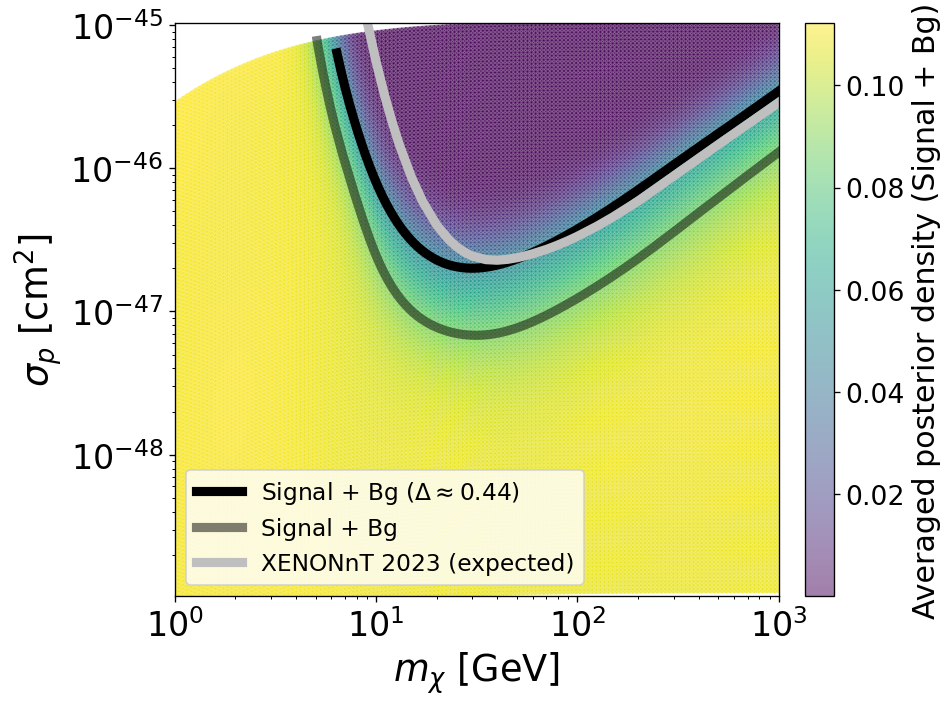

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

mesh = ax.pcolormesh(
    m_mesh,
    sigma_mesh,
    average_posterior_sigma,
    cmap="viridis",
    alpha=0.5,
    shading="gouraud",   # smooth interpolation, no cell edges
    zorder=0,
    rasterized=True,     # keeps the PDF small and avoids vector seams
)

m_prof = 10 ** logm_vals_avg
ax.plot(
    m_prof[profiled_valid],
    _cp_to_sigma_p(m_prof[profiled_valid], 10 ** profiled_logcp_limit[profiled_valid]),
    color="black",
    linewidth=5.5,
    linestyle="-",
    label=r"Signal + Bg ($\Delta \approx 0.44$)",
)

# optional: mark the threshold
#ax.axvline(10 ** logm_thresh, color="gray", ls=":", lw=2, alpha=0.7)


# Averaged posterior HPD contour for signal+background
for contour in posterior_contours:
    m_c, cp_c = 10 ** contour[:, 0], 10 ** contour[:, 1]
    y_c = _cp_to_sigma_p(m_c, cp_c)
    ax.plot(
        m_c,
        y_c,
        color="black",
        alpha=0.5,
        linewidth=5.5,
        linestyle="-",
        label="Signal + Bg",
        zorder=3,
    )
    break

#for contour in signal_only_contours:
#    m_c, cp_c = 10 ** contour[:, 0], 10 ** contour[:, 1]
#    y_c = _cp_to_sigma_p(m_c, cp_c)
#    ax.plot(
#        m_c,
#        y_c,
#        color="darkred",
#        linewidth=5.5,
#        linestyle="-",
#        alpha=0.5,
#        label="Signal only",
#        zorder=3,
#    )
#    break

plot_official_xenonnt_limit(
    ax, plot_official_xenonnt=True, y_quantity="sigma",
    color=(0.75, 0.75, 0.75), linewidth=5.5,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1, 1000)
m_rep = np.sqrt(1.0 * 1000.0)
ax.set_ylim(
    _cp_to_sigma_p(m_rep, 10 ** (-10.5)),
    _cp_to_sigma_p(m_rep, 10 ** (-8.5)),
)
ax.set_xlabel(r"$m_\chi$ [GeV]", fontsize=22)
ax.set_ylabel(r"$\sigma_p$ [cm$^{2}$]", fontsize=22)
ax.tick_params(axis="both", which="both", labelsize=20)
ax.legend(loc="lower left", fontsize=14)

cbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04,
                    label="Averaged posterior density")
cbar.ax.tick_params(labelsize=16)
cbar.set_label("Averaged posterior density (Signal + Bg)", fontsize=18)

plt.tight_layout()
#fig.savefig("...", dpi=300, bbox_inches="tight", format="pdf", transparent=True)
plt.show()